In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib
import torch
import logging 
from pathlib import Path
import random
import numpy as np
import sys


import method.datasets as ds
import method.preprocess.preprocess as ps
import method.core.pipeline as pipe
import method.models.rnn.rnn as model

from method.metrics import metrics
from logging_tools.config import setup_logging
from method.viz import plot_data, plot_results, plot_data_compare

import data_configs.base_raw_data as config

CONFIGS_PATH = Path("configs")
DATASET_CONFIG = ds.DatasetConfig.from_dict(config.EXECUTE_CONFIG["dataset"])

setup_logging()
logger = logging.getLogger(__name__)


INFO     Preprocessor.transform start

INFO     Pipeline making step 'shifter'

INFO     Pipeline making step 'drop_intervals'

INFO     Pipeline making step 'filter'

INFO     Pipeline making step 'scaler'

INFO     Pipeline making step 'feature_selector'

INFO     Pipeline making step 'splitter'

INFO     Preprocessor.transform end (0.20)s

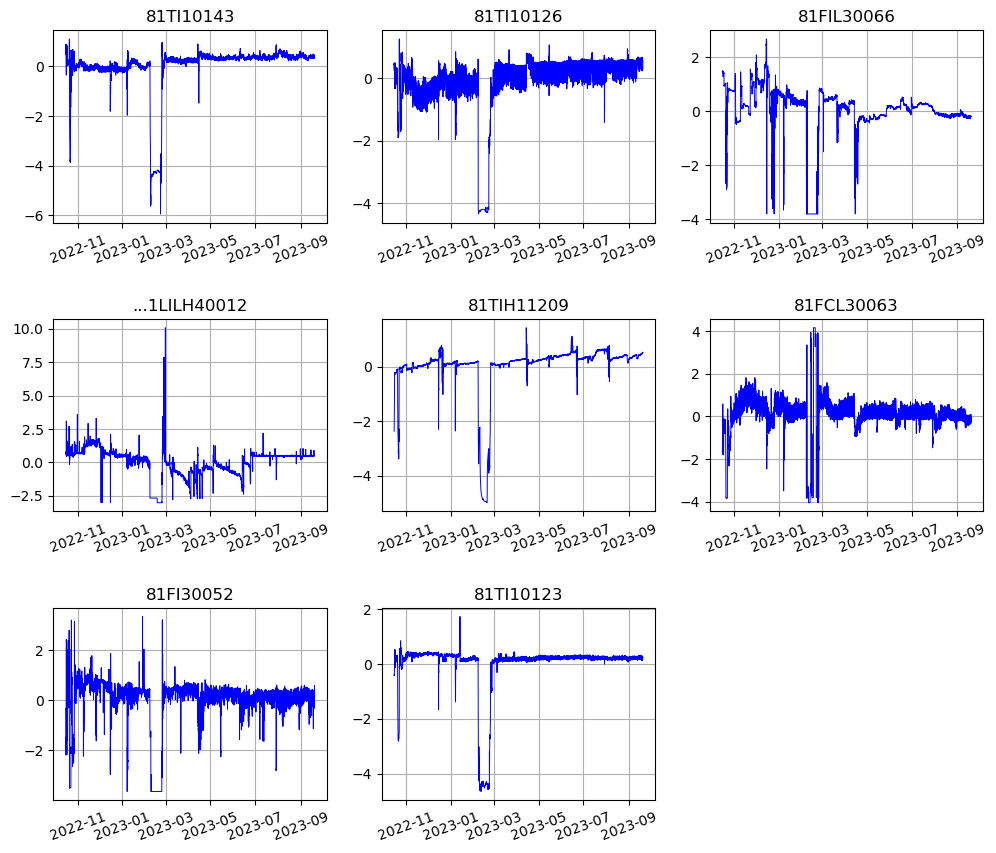

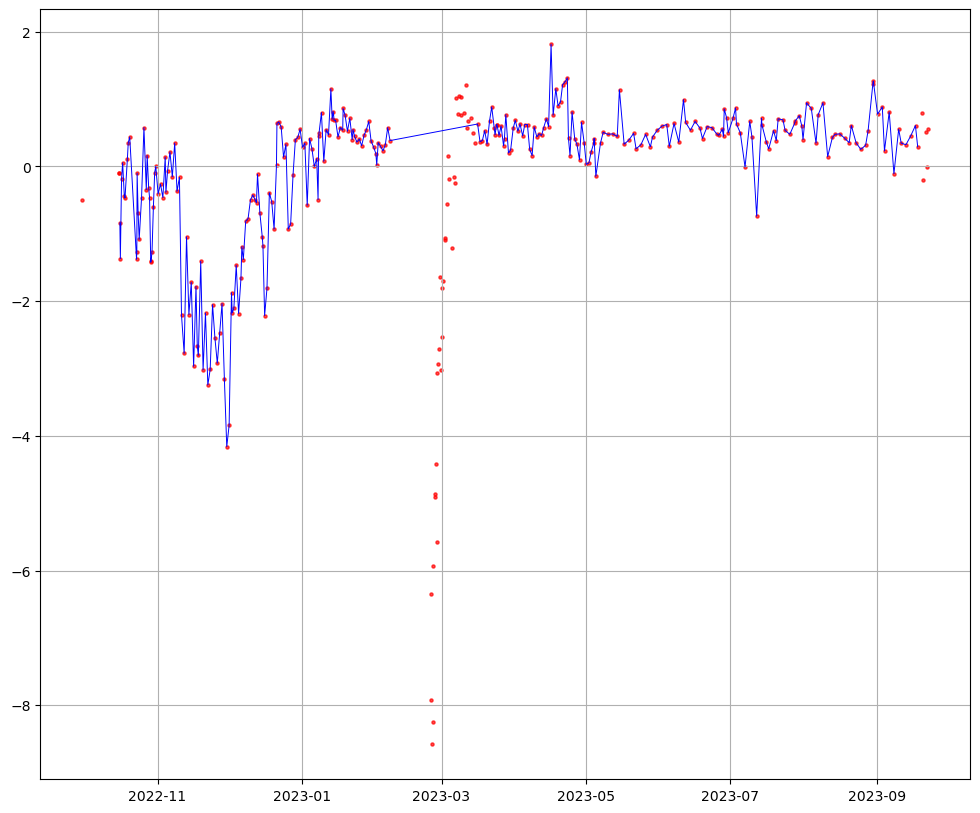

In [2]:
data_raw = ds.LoadDatasetStep(DATASET_CONFIG).fit_transform()

preprocess_config = ps.PreprocessConfig.from_dict(config.EXECUTE_CONFIG["preprocess"])
preprocessor = ps.Preprocessor(preprocess_config)

data = preprocessor.fit_transform(data_raw)
data_merged = data.merge_data()
ds_raw = data_raw.train.replace(new_y_scaler=data.train.y_scaler)
target_raw_scaled = ds_raw.scale(scale_y=True).y
target = data_merged.train.y
plot_data(data_merged.train.X.dropna(), plot_type="plot")
plot_data_compare(target_raw_scaled.dropna(), target.dropna())

INFO     RNN training model

INFO     Computing best lag using spearman correlation...

INFO     epoch 0: train: 1.8085, lr: 1.000e-02, valid: 0.3818, best_valid: 0.3818

INFO     epoch 10: train: 0.2263, lr: 1.000e-02, valid: 0.0874, best_valid: 0.0874

INFO     epoch 20: train: 0.1548, lr: 1.000e-02, valid: 0.1357, best_valid: 0.0814

...

INFO     epoch 160: train: 0.0469, lr: 1.000e-02, valid: 0.2940, best_valid: 0.0703

INFO     epoch 170: train: 0.0442, lr: 1.000e-02, valid: 0.2481, best_valid: 0.0703

INFO     epoch 180: train: 0.0373, lr: 1.000e-02, valid: 0.3431, best_valid: 0.0703

INFO     epoch 190: train: 0.0346, lr: 1.000e-02, valid: 0.2352, best_valid: 0.0703

INFO     RNN Model trained

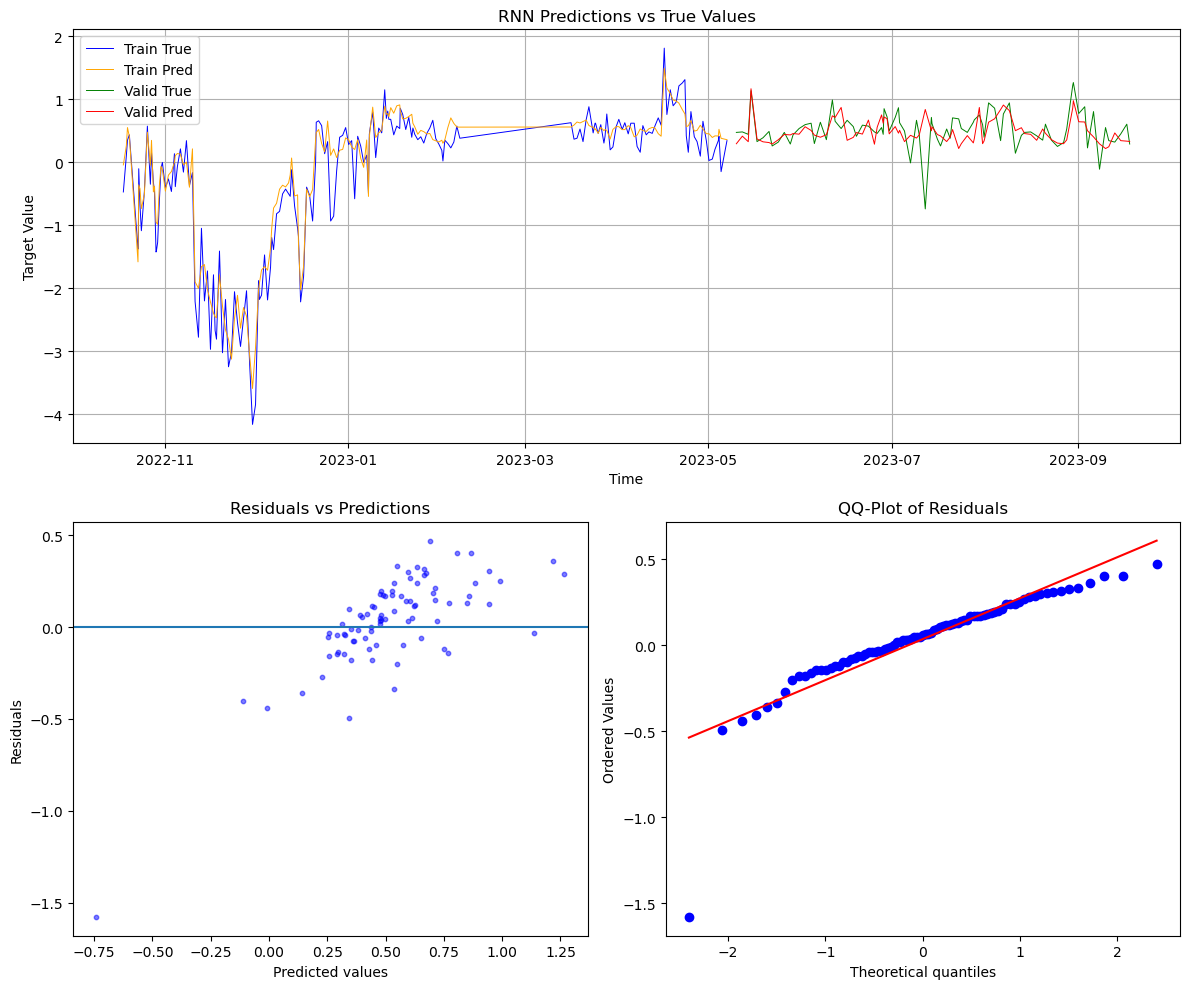

INFO                                                                                                               
         Metrics for Train:

INFO                                                                                                               
         Metrics for Valid:

INFO     MAE                  0.180549                                                                             
         rMSE                 0.265126                                                                             
         MAPE                 0.881265                                                                             
         Pearson (p-value)    0.000106                                                                             
         Pearson              0.408104                                                                             
         R2                   0.066889                                                                             
         Hinge                0.099206                                                                             
         dtype: float64

In [3]:
torch.manual_seed(0)
np.random.seed(42)
random.seed(42)

rnn_config = model.RNNConfig.from_dict(config.EXECUTE_CONFIG["model"])
rnn = model.RNN(rnn_config)

steps = [("rnn", rnn)]
full_pipeline = pipe.Pipeline(steps)  # type: ignore
result = full_pipeline.fit_transform(data)

plot_results(result)

logger.info("\nMetrics for Train:")
logger.debug(metrics(**result["train"], cone=0.1))
logger.info("\nMetrics for Valid:")
logger.info(metrics(**result["valid"], cone=0.1))